# Libs

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skimage.io
from PIL import Image
import os
from skimage import morphology
import cv2

import warnings
warnings.filterwarnings('ignore')

DIR_FILES = os.getcwd() + "/files/"

# Q1

Faça uma rotina que deixa a cor dos pimentões vermelhos da figura peppers.tif
sem alteração e que deixe os demais elementos da imagem em nível de cinza. Use
a equação de percepção humana de luminosidade para obter o nível de cinza: I =
0.21 R + 0.72 G + 0.07 B. Comente a solução usada e o resultado.

### Carregando imagem original

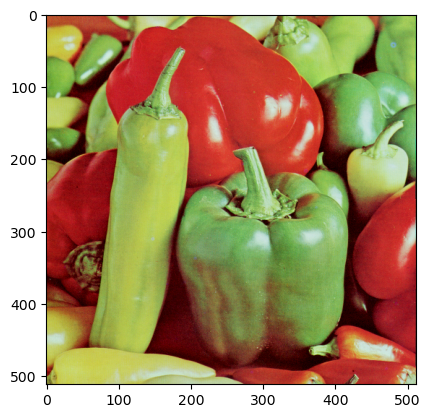

In [2]:
im1 = np.array(plt.imread(DIR_FILES + 'peppers.tiff'))
plt.imshow(im1, cmap='gray', vmin=0, vmax=255);

### Identificando áreas vermelhas e convertendo o restante em cinza

In [3]:
# Função para identificar áreas vermelhas
def is_red_pixel(r, g, b, threshold=50):
    return (r > threshold) & (r > g) & (r > b)

# Função para converter a imagem
def convert_img_gray(im):
    # Extrair os canais de cor
    r_channel = im[:, :, 0]
    g_channel = im[:, :, 1]
    b_channel = im[:, :, 2]
    
    output_image = np.zeros_like(im)
    
    # Identificar os pixels vermelhos
    red_mask = is_red_pixel(r_channel, g_channel, b_channel)
    
    # Converter pixels não vermelhos para nível de cinza
    grayscale = 0.21 * r_channel + 0.72 * g_channel + 0.07 * b_channel
    grayscale = grayscale.astype(np.uint8)
    
    # Preencher a imagem de saída
    output_image[:, :, 0] = np.where(red_mask, r_channel, grayscale)
    output_image[:, :, 1] = np.where(red_mask, g_channel, grayscale)
    output_image[:, :, 2] = np.where(red_mask, b_channel, grayscale)
    
    return output_image

### Imagem original e convertida

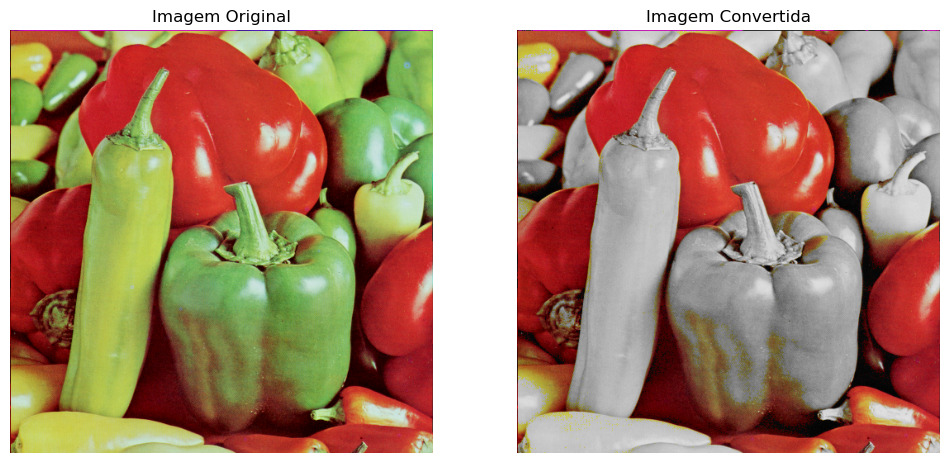

In [4]:
# Converter a imagem
converted_image = convert_img_gray(im1)

# Exibir a imagem original e a imagem convertida
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im1,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Imagem Original')
ax[0].axis('off')
ax[1].imshow(converted_image,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Imagem Convertida')
ax[1].axis('off')
plt.show()

## Convertendo com HSV [TESTE]

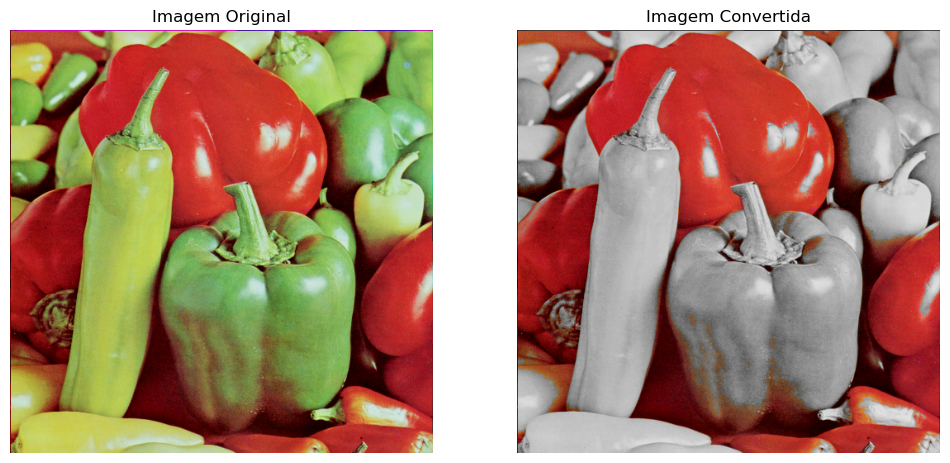

In [5]:
# Função para converter RGB para HSV
def RGB2HSV(im):
    im = im / 255.0
    r, g, b = im[:,:,0], im[:,:,1], im[:,:,2]
    maxc = np.max(im, axis=2)
    minc = np.min(im, axis=2)
    v = maxc
    s = (maxc - minc) / maxc
    s[maxc == 0] = 0
    rc = (maxc - r) / (maxc - minc)
    gc = (maxc - g) / (maxc - minc)
    bc = (maxc - b) / (maxc - minc)
    h = np.zeros_like(maxc)
    h[minc == maxc] = 0
    h[r == maxc] = (bc - gc)[r == maxc]
    h[g == maxc] = 2.0 + (rc - bc)[g == maxc]
    h[b == maxc] = 4.0 + (gc - rc)[b == maxc]
    h = (h / 6.0) % 1.0
    return np.dstack((h, s, v))

# Função para identificar áreas vermelhas
def is_red_pixel(h, s, v, h_threshold_low=0.0, h_threshold_high=0.1, s_threshold=0.5):
    return ((h >= h_threshold_low) & (h <= h_threshold_high) & (s >= s_threshold)) | ((h >= 0.9) & (h <= 1.0) & (s >= s_threshold))

# Função para converter a imm
def convert2gray(im):
    # Converter para HSV
    hsv_im = RGB2HSV(im)
    h_channel = hsv_im[:, :, 0]
    s_channel = hsv_im[:, :, 1]
    v_channel = hsv_im[:, :, 2]
    
    # Inicializar a imm de saída
    output_im = np.zeros_like(im)
    
    # Identificar os pixels vermelhos
    red_mask = is_red_pixel(h_channel, s_channel, v_channel)
    
    # Converter pixels não vermelhos para nível de cinza
    r_channel = im[:, :, 0]
    g_channel = im[:, :, 1]
    b_channel = im[:, :, 2]
    grayscale = 0.21 * r_channel + 0.72 * g_channel + 0.07 * b_channel
    grayscale = grayscale.astype(np.uint8)
    
    # Preencher a imm de saída
    output_im[:, :, 0] = np.where(red_mask, r_channel, grayscale)
    output_im[:, :, 1] = np.where(red_mask, g_channel, grayscale)
    output_im[:, :, 2] = np.where(red_mask, b_channel, grayscale)
    
    return output_im
# Converter a imm
converted_im = convert2gray(im1)

# Exibir a imm original e a imm convertida
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im1,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Imagem Original')
ax[0].axis('off')
ax[1].imshow(converted_im,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Imagem Convertida')
ax[1].axis('off')
plt.show()

Utilizando o RGB a maior parte das cores foi convertida para cinza, porém algumas partes não foram totalmente convertidas. Testei então realizar a conversão utilizando o HSV para verificar o resultado.
Primeiramente são identificados os pixels vermelhos na imagem de acordo com um limiar na camada R, logo depois todos os pixels que não foram identificados como vermelhos são convertidos para escala de cinza utilizando a equação pré estabelecida.

# Q2

Faça a equalização da imagem colorida colorful-red-blue.png de duas maneiras:
equalizando cada canal individual do espaço RGB e outra equalizando o canal I
do espaço HSI (implemente o código de conversão). Compare os resultados e
informe qual que seria a abordagem mais correta. 

### Carregando imagem original

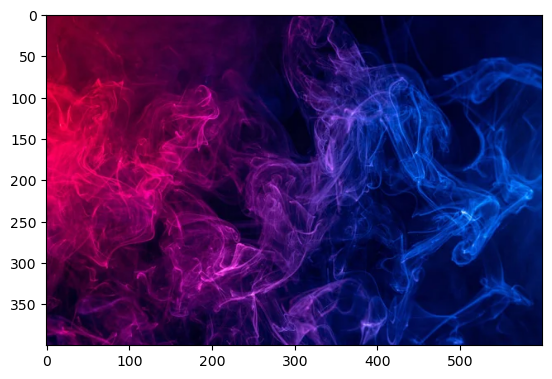

In [6]:
# im = np.array(plt.imread(DIR_FILES + 'colorful-red-blue.png'))
# plt.imshow(im, cmap='gray', vmin=0, vmax=255);

im2 = cv2.imread(DIR_FILES + 'colorful-red-blue.png')
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)
plt.imshow(im2);

### Equalizando cada canal RGB

In [7]:
# Geração do histograma
def histograma(image):
    vet = np.zeros(256, dtype=np.uint64)
    teste = image.ravel()
    for pixel in teste:
        vet[int(pixel)] = vet[int(pixel)]+1
    return vet
    
# Equalização global de histograma
def equalize(image):
    hist = histograma(image)
    image_eq = np.zeros(image.shape)
    cdf = np.cumsum(hist)
    s = ((cdf - 0) / (image.shape[0]*image.shape[1] - 0)) * 255
    s = np.round(s)
    image_eq = s[image].astype(np.uint64)
    return image_eq

In [8]:
# Equalização usando canais R, G e B
eq1_im = np.zeros(im2.shape).astype(np.uint64)
eq1_im[:,:,0] = equalize(im2[:,:,0].astype(np.uint64)) #R
eq1_im[:,:,1] = equalize(im2[:,:,1].astype(np.uint64)) #G
eq1_im[:,:,2] = equalize(im2[:,:,2].astype(np.uint64)) #B

### Equalizando canal I no espaço HSI

In [9]:
def normalized_channels(image):
    if np.max(image) > 1:
        image = image/255
    return image[:,:,0],image[:,:,1],image[:,:,2]


def RGB2HSI(image):
    image_convert = np.zeros(image.shape,dtype=np.uint64)
    [R,G,B] = normalized_channels(image)

    H = np.zeros(R.shape)
    num = 1/2 * ((R-G)+(R-B))
    den = 0.000001 + np.sqrt((R-G)**2+(R-B)*(G-B))
    theta = np.rad2deg(np.arccos(num/den))
    H[B<=G] = theta[B<=G]
    H[B>G] = 360 - theta[B>G]



    H = H / 360
    S = 1 - 3*np.minimum(np.minimum(R,G),B)/((R+G+B)+0.000001)
    I = 1/3 * (R+G+B)

    image_convert[:,:,0] = H * 255
    image_convert[:,:,1] = S * 255
    image_convert[:,:,2] = I * 255

    return image_convert

def HSI2RGB(image):
    image_convert = np.zeros(image.shape,dtype=np.uint64)
    
    [H,S,I] = normalized_channels(image)

    R = np.zeros(H.shape)
    G = np.zeros(H.shape)
    B = np.zeros(H.shape)

    H = H * 360
    
    for l in range(image.shape[0]):
        for c in range(image.shape[1]): 
            if H[l][c] >= 0 and H[l][c] < 120:
                h = H[l][c]
                s = S[l][c]
                i = I[l][c]
                B[l][c] = i * (1 - s)
                R[l][c] = i * (1 + s * np.cos(np.deg2rad(h)) / (np.cos(np.deg2rad(60-h))))
                G[l][c] = 3 * i - (R[l][c]+B[l][c])

            elif H[l][c] >= 120 and H[l][c] < 240:
                h = H[l][c] - 120
                s = S[l][c]
                i = I[l][c]
                R[l][c] = i * (1 - s)
                G[l][c] = i * (1 + s * np.cos(np.deg2rad(h)) / (np.cos(np.deg2rad(60-h))))
                B[l][c] = 3 * i - (R[l][c]+G[l][c])
             
            elif H[l][c] >= 240 and H[l][c] < 360:
                h = H[l][c] - 240
                s = S[l][c]
                i = I[l][c]
                G[l][c] = i * (1 - s)
                B[l][c] = i * (1 + s * np.cos(np.deg2rad(h)) / (np.cos(np.deg2rad(60-h))))
                R[l][c] = 3 * i - (G[l][c]+B[l][c])

    image_convert[:,:,0] = R * 255
    image_convert[:,:,1] = G * 255
    image_convert[:,:,2] = B * 255

    return image_convert

im_HSI = RGB2HSI(im2)
eq_HSI = im_HSI.copy()
eq_HSI[:,:,2] = equalize(eq_HSI[:,:,2])
eq2_im = HSI2RGB(eq_HSI) # retorna valores fora do intervalo [0,255]
eq2_im = (eq2_im-np.min(eq2_im))/(np.max(eq2_im)-np.min(eq2_im))*255 # deixando os valores no intervalo [0,255]
eq2_im = eq2_im.astype(np.uint64) 

### Plotando histogramas

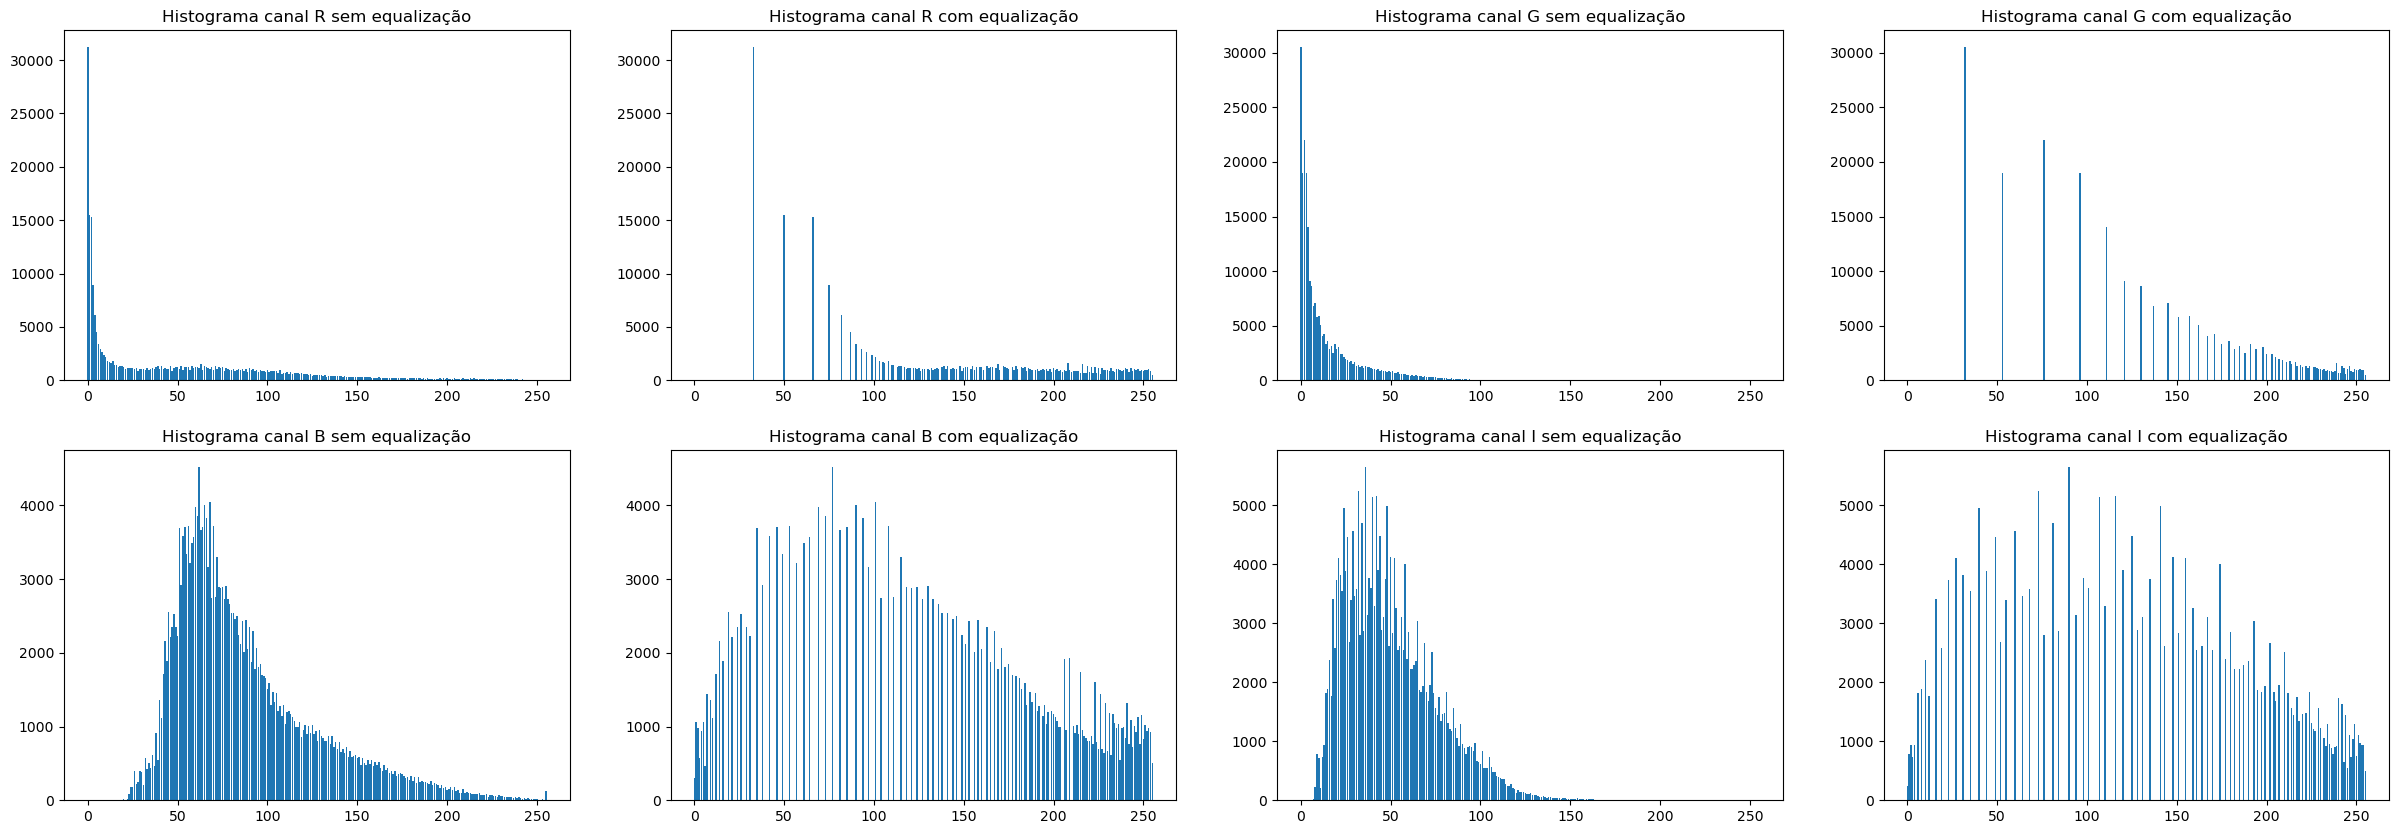

In [10]:
# Plot dos histogramas
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(30, 10))
axs[0,0].bar(range(0,256),histograma(im2[:,:,0]))
axs[0,1].bar(range(0,256),histograma(eq1_im[:,:,0]))
axs[0,2].bar(range(0,256),histograma(im2[:,:,1]))
axs[0,3].bar(range(0,256),histograma(eq1_im[:,:,1]))
axs[1,0].bar(range(0,256),histograma(im2[:,:,2]))
axs[1,1].bar(range(0,256),histograma(eq1_im[:,:,2]))
axs[1,2].bar(range(0,256),histograma(im_HSI[:,:,2]))
axs[1,3].bar(range(0,256),histograma(eq_HSI[:,:,2]))
axs[0,0].set_title('Histograma canal R sem equalização')
axs[0,1].set_title('Histograma canal R com equalização');
axs[0,2].set_title('Histograma canal G sem equalização');
axs[0,3].set_title('Histograma canal G com equalização');
axs[1,0].set_title('Histograma canal B sem equalização')
axs[1,1].set_title('Histograma canal B com equalização');
axs[1,2].set_title('Histograma canal I sem equalização');
axs[1,3].set_title('Histograma canal I com equalização');
plt.show() 

### Plotando imagens finais

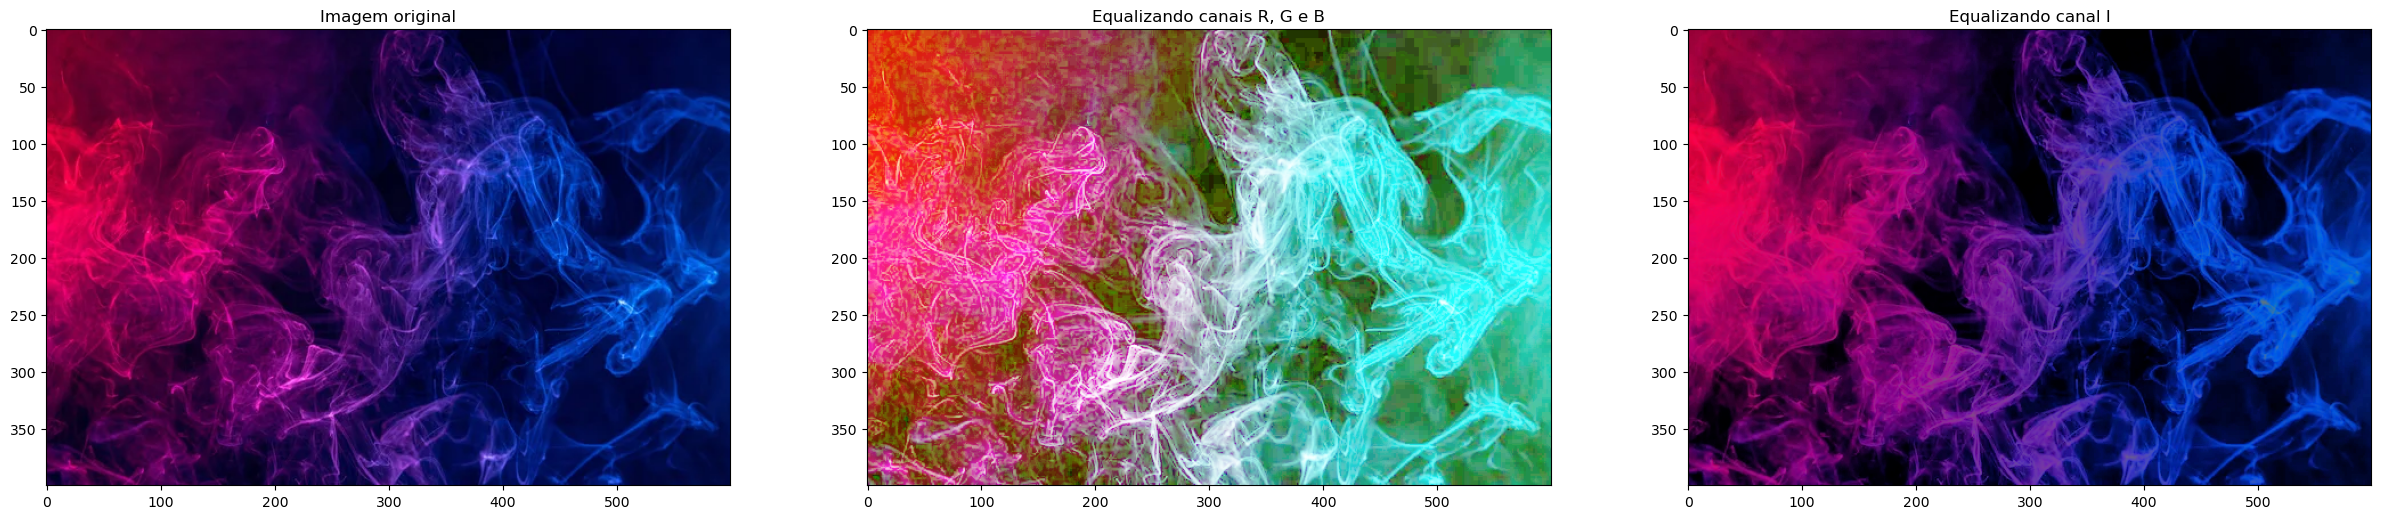

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(30, 30))
axs[0].imshow(im2,cmap='gray',vmin=0,vmax=255)
axs[1].imshow(eq1_im,cmap='gray',vmin=0,vmax=255)
axs[2].imshow(eq2_im,cmap='gray',vmin=0,vmax=255)
axs[0].set_title('Imagem original')
axs[1].set_title('Equalizando canais R, G e B');
axs[2].set_title('Equalizando canal I');
plt.show()

O resultado obtido para a equalização, ao utilizar os canais R, G e B separadamente, não foi satisfatório, pois distorceu as cores originais. Isso ocorre porque as combinações de R, G e B resultam em diferenças significativas. É possível observar que nas regiões mais escuras apareceu uma coloração verde que não estava presente na imagem original, o que é não pode ocorrer. Em contrapartida, a equalização do canal de intensidade da imagem em HSI foi mais eficaz, mantendo as regiões com as mesmas cores, uma vez que preserva os canais de matiz e saturação inalterados.

# Q3

Implemente os processos morfológicos de erosão e dilatação para imagens
binárias, considerando que seja possível definir um elemento estruturante
quadrado ou retangular cujos lados sejam um número ímpar. Considere que a
origem do elemento estruturante seja o centro de gravidade do elemento. Aplique
as operações de erosão e dilatação na imagem Fig9.11(a).jpg de forma a
reproduzir o exemplo 9.4 do livro texto em português (3ª edição).

### Carregando imagem original

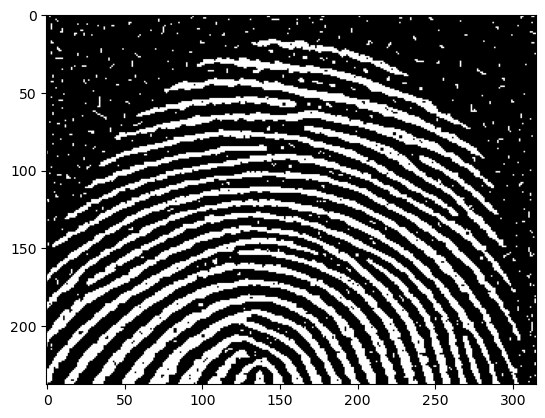

In [12]:
im3 = np.array(plt.imread(DIR_FILES + 'Fig9.11(a).jpg'))
plt.imshow(im3, cmap='gray', vmin=0, vmax=255);

### Binarizando e aplicando erosão e dilatação

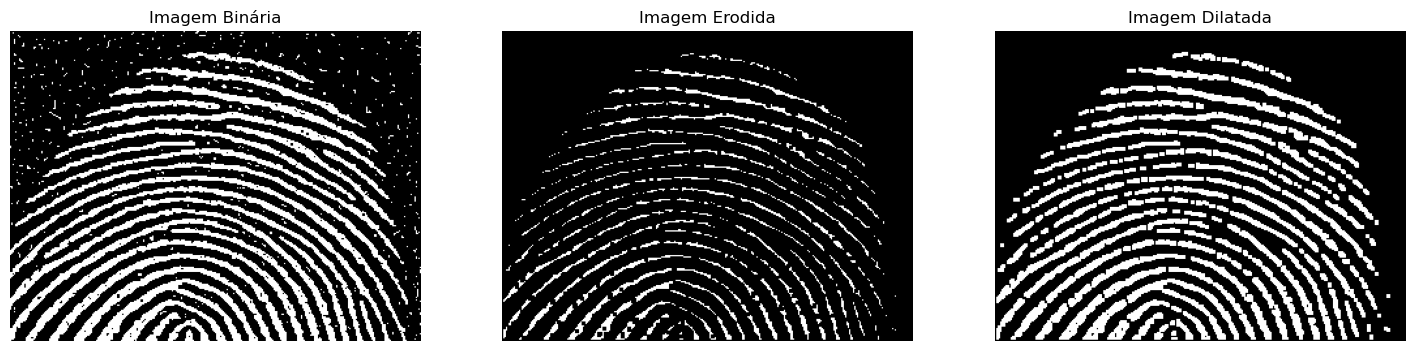

In [13]:
def binarize_image(image, threshold=128):
    binary_image = np.where(image > threshold, 1, 0)
    return binary_image

def create_structuring_element(shape, size, w, h):
    if shape == 'square':
        return np.ones((size, size), dtype=np.uint8)
    elif shape == 'rectangle':
        return np.ones((w,h), dtype=np.uint8)

def erode(image, structuring_element):
    se_height, se_width = structuring_element.shape
    se_center_y, se_center_x = se_height // 2, se_width // 2
    image_height, image_width = image.shape
    
    eroded_image = np.zeros_like(image)
    
    for y in range(se_center_y, image_height - se_center_y):
        for x in range(se_center_x, image_width - se_center_x):
            region = image[y - se_center_y:y + se_center_y + 1, x - se_center_x:x + se_center_x + 1]
            if np.all(region == structuring_element):
                eroded_image[y, x] = 1
    
    return eroded_image

def dilate(image, structuring_element):
    se_height, se_width = structuring_element.shape
    se_center_y, se_center_x = se_height // 2, se_width // 2
    image_height, image_width = image.shape
    
    dilated_image = np.zeros_like(image)
    
    for y in range(se_center_y, image_height - se_center_y):
        for x in range(se_center_x, image_width - se_center_x):
            region = image[y - se_center_y:y + se_center_y + 1, x - se_center_x:x + se_center_x + 1]
            if np.any(region == structuring_element):
                dilated_image[y, x] = 1
    
    return dilated_image

# Binarizar a imagem
binary_image = binarize_image(im3)

# Criar um elemento estruturante quadrado de tamanho 3x3
structuring_element = create_structuring_element('square', 3, w=3, h=4)

# Aplicar erosão
eroded_image = erode(binary_image, structuring_element)

# Aplicar dilatação
dilated_image = dilate(eroded_image, structuring_element)


# Exibir as imagens
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(binary_image,cmap='gray')
ax[0].set_title('Imagem Binária')
ax[0].axis('off')
ax[1].imshow(eroded_image,cmap='gray')
ax[1].set_title('Imagem Erodida')
ax[1].axis('off')
ax[2].imshow(dilated_image,cmap='gray')
ax[2].set_title('Imagem Dilatada')
ax[2].axis('off')
plt.show()

Foi utilizado um elemento estruturante quadrado de tamanho 3x3 como no exemplo 9.4 do livro texto. É possível perceber que a maior parte do ruído foi eliminada com esse tratamento por apresentar, em geral, tamanho menor que o elemento estruturante.

# Q4

Aplique Sobel na imagem Fig10.10(a).jpg para obter as bordas. Use um limiar
adequado e comente o resultado. Talvez haja a necessidade de suavizar a imagem. 

### Carregando imagem original

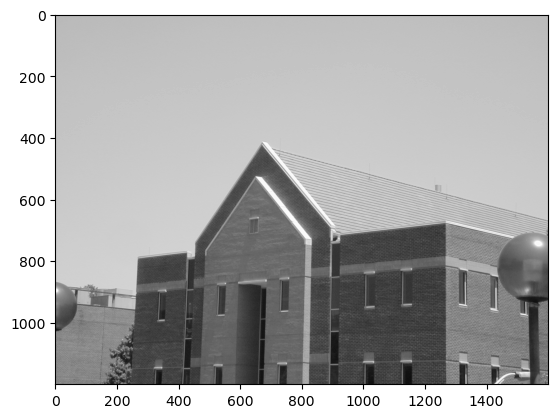

In [14]:
im4 = np.array(plt.imread(DIR_FILES + 'Fig10.10(a).jpg'))
plt.imshow(im4, cmap='gray', vmin=0, vmax=255);

### Aplicando sobel

In [15]:
def conv(image,mask):
    mask = np.flip(mask)
    cropped_image = np.zeros(((image.shape[0]-2*mask.shape[0]//2),(image.shape[1]-2*mask.shape[1]//2)))
    for l in range(cropped_image.shape[0]):
        for c in range(cropped_image.shape[1]):
            result = np.multiply(image[l:l+mask.shape[0],c:c+mask.shape[1]], mask)
            cropped_image[l,c] = np.sum(result)
    return cropped_image

def sobel_filter(image):
    gx = [[-1,-2,-1],[0,0,0],[1,2,1]]
    gy = [[-1,0,1],[-2,0,2],[-1,0,1]]
    convx = conv(image,gx)
    convy = conv(image,gy)
    filtered_image = np.sqrt(convx**2+convy**2)
    return filtered_image

im4_filtered = sobel_filter(im4)

### Aplicando filtro de média

In [16]:
def mean_filter(image,N):
    mask = 1/N**2 * np.ones((N,N))
    image = np.delete(image,(1), axis = 0)
    image = np.delete(image,(1), axis = 1)
    pad = 3
    padded_image = np.pad(image, pad_width=pad, mode='reflect')
    filtered_image = conv(padded_image,mask)
    return filtered_image

im4_suavizada = mean_filter(im4,5)
im4_suavizada_sobel = sobel_filter(im4_suavizada)

### Plotando imagens

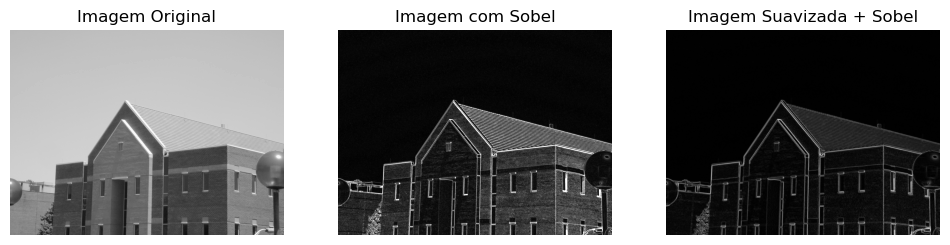

In [17]:
# Exibir a imm original e a imm convertida
fig, ax = plt.subplots(1, 3, figsize=(12, 12))
ax[0].imshow(im4,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Imagem Original')
ax[0].axis('off')
ax[1].imshow(im4_filtered,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Imagem com Sobel')
ax[1].axis('off')
ax[2].imshow(im4_suavizada_sobel,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Imagem Suavizada + Sobel')
ax[2].axis('off')
plt.show()

Inicialmente foi aplicado o filtro de sobel na imagem sem realizar a suavização e é possível perceber que as bordas são destacadas porém os tijolos presentes na parede do edifício ainda estão presentes na imagem de forma acentudada. Dessa forma foi aplicado um filtro de média de tamanho 5x5 para suavizar a imagem e assim aplicar o filtro de sobel, com isso foi possível destacar melhor os contornos da imagem evitando as texturas da mesma.

# Q5

Baseado no Capítulo 10 proponha uma abordagem de segmentação do
comprimido da foto comprimido.jpg. Compare o resultado da segmentação com a
imagem mascara.png. Conte quantos pixels foram segmentados errados. Explique
a sua solução e comente sobre os resultados. 

### Carregando imagem

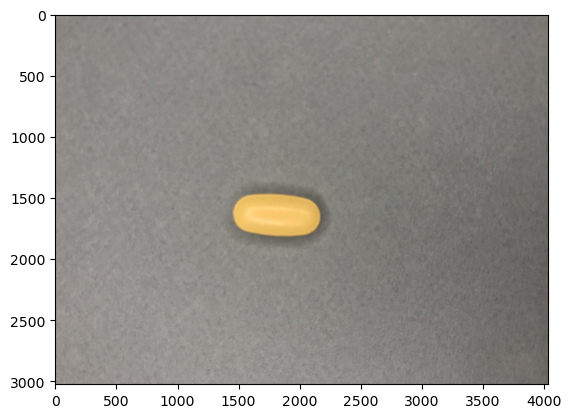

In [18]:
im5 = np.array(plt.imread(DIR_FILES + 'comprimido.jpg'))
plt.imshow(im5, cmap='gray', vmin=0, vmax=255);

## Convertendo para escala de cinza

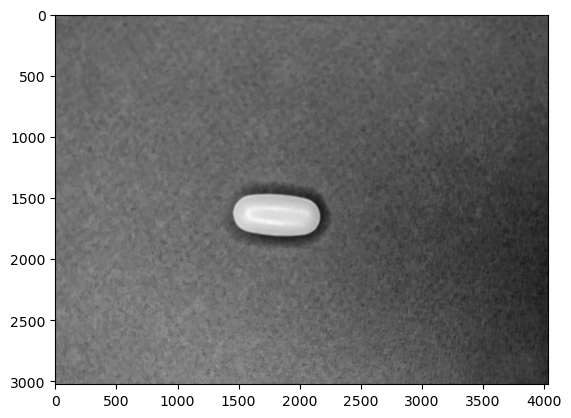

In [19]:
# Função para converter a imagem colorida para escala de cinza
def convert_to_grayscale(color_image):
    R = color_image[:, :, 0]
    G = color_image[:, :, 1]
    B = color_image[:, :, 2]
    grayscale_image = 0.21 * R + 0.72 * G + 0.07 * B
    return grayscale_image.astype(np.uint8)

im5_grayscale = convert_to_grayscale(im5)
plt.imshow(im5_grayscale, cmap='gray');

## Histograma da imagem

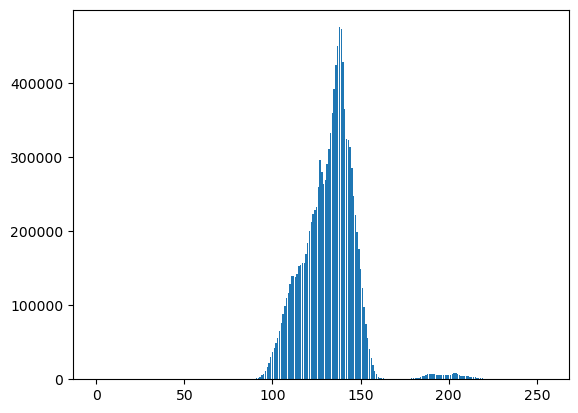

In [20]:
def histo(image):
    vet = np.zeros(256, dtype=np.uint64)
    for pixel in image.ravel():
        vet[pixel] = vet[pixel]+1
    return vet

plt.bar(range(0,256),histo(im5_grayscale));

## Selecionando uma região menor da imagem

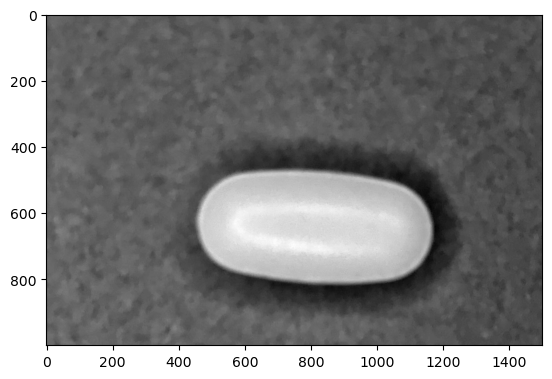

In [21]:
# Função para selecionar uma região específica da imagem
def select_region(image, top, bottom, left, right):
    return image[top:bottom, left:right]

# Definir as coordenadas da região específica (top, bottom, left, right)
top, bottom, left, right = 1000, 2000, 1000, 2500

# Selecionar a região específica onde está o comprimido
comprimido = select_region(im5_grayscale, top, bottom, left, right)
plt.imshow(comprimido,cmap='gray');

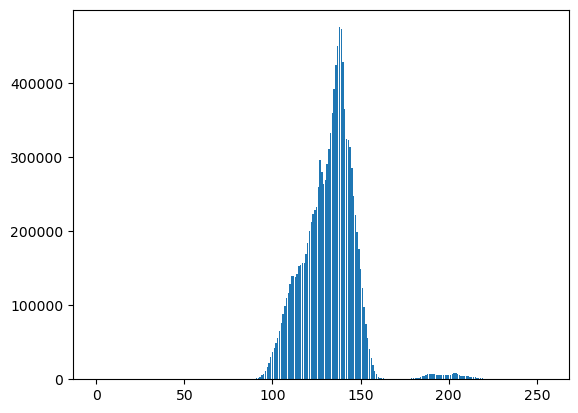

In [22]:
def histo(image):
    vet = np.zeros(256, dtype=np.uint64)
    for pixel in image.ravel():
        vet[pixel] = vet[pixel]+1
    return vet

plt.bar(range(0,256),histo(im5_grayscale));

## Aplicando OTSU

In [23]:
# Função para aplicar o método de Otsu
def apply_otsu(image):
    hist, bin_edges = np.histogram(image.flatten(), bins=256, range=(0, 255))
    total_pixels = image.size
    
    current_max, threshold = 0, 0
    sum_total, sum_foreground = 0, 0
    weight_background, weight_foreground = 0, 0
    
    for i in range(256):
        sum_total += i * hist[i]
        
    for i in range(256):
        weight_background += hist[i]
        if weight_background == 0:
            continue
        weight_foreground = total_pixels - weight_background
        if weight_foreground == 0:
            break
        sum_foreground += i * hist[i]
        mean_background = sum_foreground / weight_background
        mean_foreground = (sum_total - sum_foreground) / weight_foreground
        between_class_variance = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
        if between_class_variance > current_max:
            current_max = between_class_variance
            threshold = i
    
    otsu_thresholded_image = (image > threshold).astype(np.uint8) * 255
    return threshold

limiar = apply_otsu(comprimido)
print("Limiar OTSU: " + str(limiar))

im5_binary = np.where(im5_grayscale < limiar, 0, 1)

Limiar OTSU: 165


## Calculando erros na segmentação

In [24]:
# Função para calcular os erros de segmentação
def count_different_pixels(image1, image2):
    # Contar pixels diferentes
    different_pixels = np.count_nonzero(image1 != image2)
    return different_pixels

def rotate_90_antihorario(image):
    rotated_image = np.rot90(image / 255, k=1) * 255
    return rotated_image.astype(np.uint8)

im_mask = np.array(plt.imread(DIR_FILES + 'mascara.png'))
im_mask *= 255
im_mask = im_mask.astype(np.uint8)
im_mask = rotate_90_antihorario(im_mask)

errors = count_different_pixels(im5_binary,im_mask)
print("Número de pixels diferentes na segmentação: ", errors)

Número de pixels diferentes na segmentação:  205365


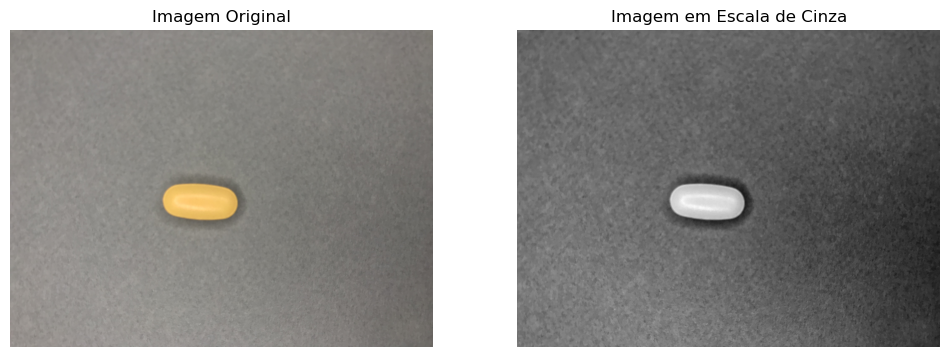

In [25]:
# Exibir as imagens
fig, ax = plt.subplots(1, 2, figsize=(12, 12))
ax[0].imshow(im5)
ax[0].set_title('Imagem Original')
ax[0].axis('off')
ax[1].imshow(im5_grayscale, cmap='gray')
ax[1].set_title('Imagem em Escala de Cinza')
ax[1].axis('off')

plt.show()

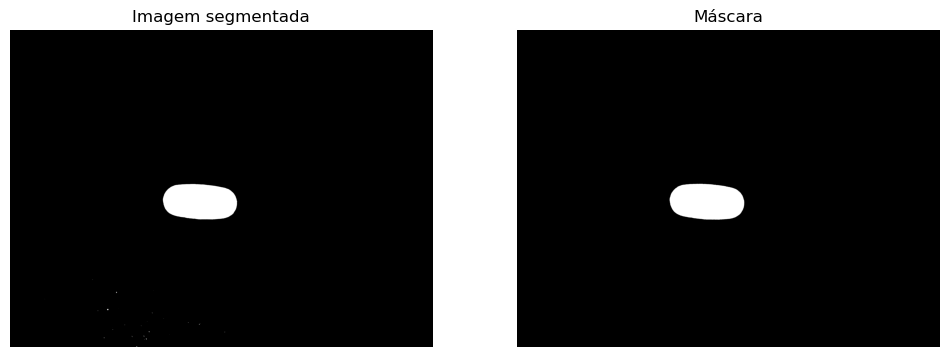

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 12))
ax[0].imshow(im5_binary, cmap='gray')
ax[0].set_title('Imagem segmentada')
ax[0].axis('off')
ax[1].imshow(im_mask, cmap='gray')
ax[1].set_title('Máscara')
ax[1].axis('off')

plt.show()

Ao utilizar o OTSU em toda a imagem o resultado foi muito ruim, acredito que devido ao comprimido ser muito pequeno em relação ao fundo, como o fundo era praticamente o mesmo em toda a imagem selecionei uma região menor contendo o comprimido para aplicar o OTSU. Para verificar o erro, carreguei a mascára que estava ficando com as dimensões trocadas então rotacionei a imagem para as duas ficarem com as mesmas dimensões então calculei a quantidade de pixels diferentes.

# Q6

Reproduza o exemplo 11.4 do livro texto na imagem Fig11.10.jpg para obter a
sua assinatura. Pode usar as equações na seção 11.3.4 para descobrir o centro do
objeto (𝑥̅, 𝑦̅).

## Carregando imagem

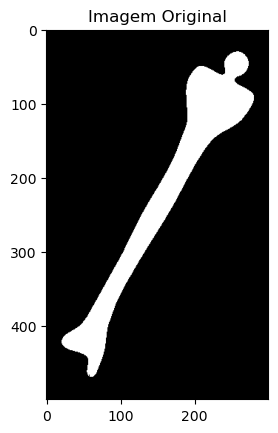

In [27]:
im6 = np.array(plt.imread(DIR_FILES + 'Fig11.10.jpg'))
plt.imshow(im6, cmap='gray', vmin=0, vmax=255);
plt.title("Imagem Original");

## Aplicando filtro de média para suavização

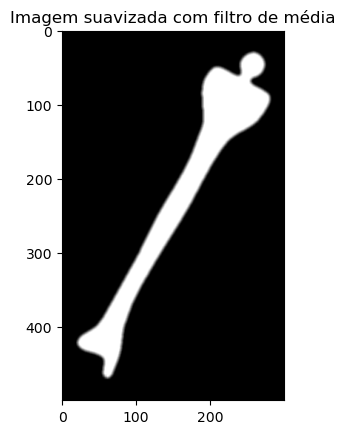

In [28]:
def mean_filter(image,N):
    mask = 1/N**2 * np.ones((N,N))
    image = np.delete(image,(1), axis = 0)
    image = np.delete(image,(1), axis = 1)
    pad = 3
    padded_image = np.pad(image, pad_width=pad, mode='reflect')
    filtered_image = conv(padded_image,mask)
    return filtered_image

im6 = mean_filter(im6,5)
plt.imshow(im6,cmap='gray');
plt.title('Imagem suavizada com filtro de média');

## Aplicando Sobel

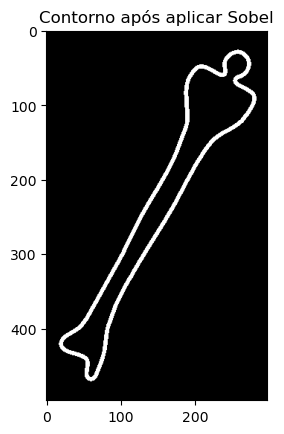

In [29]:
def conv(image,mask):
    mask = np.flip(mask)
    cropped_image = np.zeros(((image.shape[0]-2*mask.shape[0]//2),(image.shape[1]-2*mask.shape[1]//2)))
    for l in range(cropped_image.shape[0]):
        for c in range(cropped_image.shape[1]):
            result = np.multiply(image[l:l+mask.shape[0],c:c+mask.shape[1]], mask)
            cropped_image[l,c] = np.sum(result)
    return cropped_image

def sobel_filter(image):
    gx = [[-1,-2,-1],[0,0,0],[1,2,1]]
    gy = [[-1,0,1],[-2,0,2],[-1,0,1]]
    convx = conv(image,gx)
    convy = conv(image,gy)
    filtered_image = np.sqrt(convx**2+convy**2)
    return filtered_image

im6_filtered = sobel_filter(im6)
im6_filtered = np.array(im6_filtered) > 128  #Binarizando imagem após retornar o contorno
plt.imshow(im6_filtered, cmap='gray');
plt.title("Contorno após aplicar Sobel");

## Calculando centro e assinatura da imagem

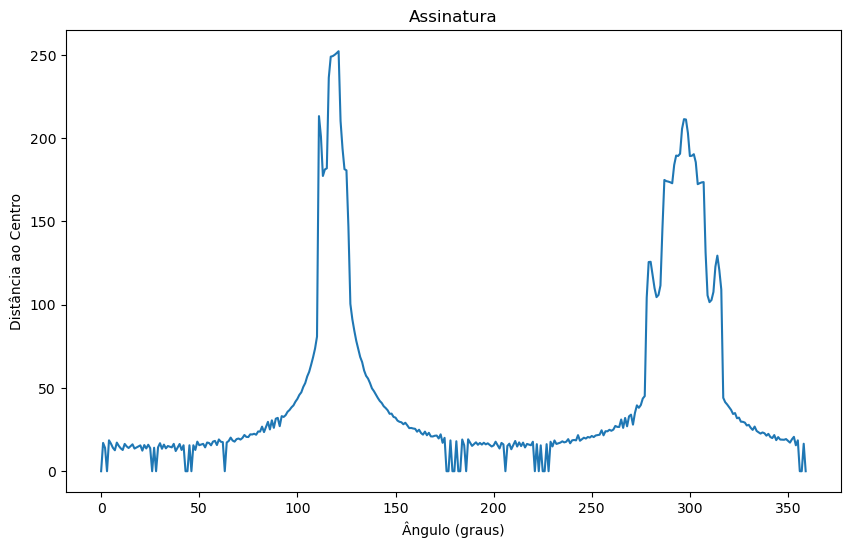

In [31]:
# Função para calcular os momentos da imagem
def calculate_moments(binary_image):
    m00 = np.sum(binary_image)
    m10 = np.sum(np.arange(binary_image.shape[1]) * np.sum(binary_image, axis=0))
    m01 = np.sum(np.arange(binary_image.shape[0]) * np.sum(binary_image, axis=1))
    return m00, m10, m01

# Função para calcular o centroide do objeto
def calculate_centroid(m00, m10, m01):
    x_bar = m10 / m00
    y_bar = m01 / m00
    return x_bar, y_bar

# Função para calcular a assinatura do objeto
def calculate_signature(boundary_image, x_bar, y_bar):
    y_coords, x_coords = np.where(boundary_image)
    angles = np.arctan2(y_coords - y_bar, x_coords - x_bar) * 180 / np.pi
    distances = np.sqrt((x_coords - x_bar)**2 + (y_coords - y_bar)**2)
    
    # Normalizar ângulos para 0° a 360°
    angles = np.mod(angles + 360, 360)
    
    # Agrupar distâncias por ângulo
    signature = np.zeros(360)
    for angle in range(360):
        mask = (angles >= angle) & (angles < angle + 1)
        if np.any(mask):
            signature[angle] = np.mean(distances[mask])
    
    return signature

# Calcular os momentos da imagem
m00, m10, m01 = calculate_moments(im6)

# Calcular o centroide do objeto
x_bar, y_bar = calculate_centroid(m00, m10, m01)

# Calcular a assinatura do objeto
signature = calculate_signature(im6_filtered, x_bar, y_bar)

# Exibir a assinatura
plt.figure(figsize=(10, 6))
plt.plot(signature)
plt.title('Assinatura')
plt.xlabel('Ângulo (graus)')
plt.ylabel('Distância ao Centro')
plt.show()

# Q7

Baseado na Tabela 11.3 do livro texto (3ª edição) calcule três métricas extraídas
da matriz de co-ocorrência (implemente a obtenção da matriz de co-ocorrência na
orientação horizontal com distância de um pixel da esquerda para a direita).
Obtenha essas três métricas para as imagens Fig11.21(a).jpg e Prob11.24.jpg. 

## Carregando imagens

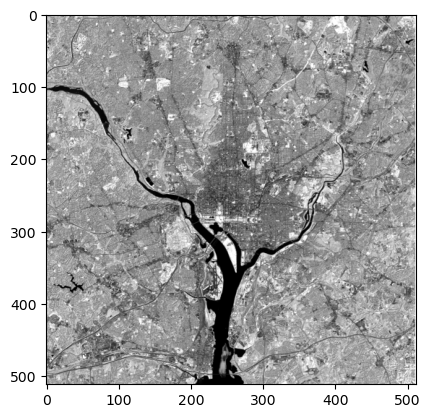

In [32]:
im7_1 = np.array(plt.imread(DIR_FILES + 'Fig11.21(a).jpg'))
plt.imshow(im7_1, cmap='gray', vmin=0, vmax=255);

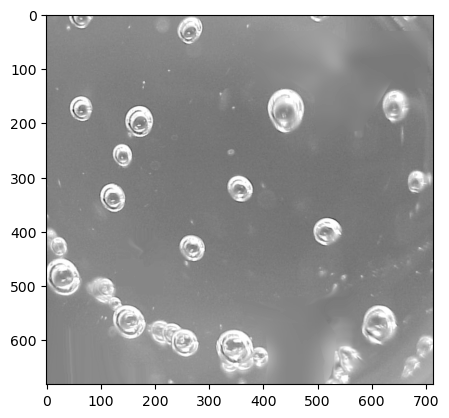

In [33]:
im7_2 = np.array(plt.imread(DIR_FILES + 'Prob11.24.jpg'))
plt.imshow(im7_2, cmap='gray', vmin=0, vmax=255);

## Calculando matriz de co-ocorrência e suas métricas

In [34]:
# Função para calcular a matriz de co-ocorrência
def coocor_matrix(image):
    max_gray_level = 256
    cooccurrence_matrix = np.zeros((max_gray_level, max_gray_level), dtype=np.uint32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1] - 1):
            row_pixel = image[i, j]
            col_pixel = image[i, j + 1]
            cooccurrence_matrix[row_pixel, col_pixel] += 1

    return cooccurrence_matrix

# Função para calcular as métricas da matriz de co-ocorrência
def metrics(cooccurrence_matrix):
    total_pairs = np.sum(cooccurrence_matrix)
    normalized_cooccurrence_matrix = cooccurrence_matrix / total_pairs

    contrast = 0
    correlation = 0
    energy = 0
    mean_i = np.mean(np.arange(cooccurrence_matrix.shape[0]))
    mean_j = np.mean(np.arange(cooccurrence_matrix.shape[1]))
    std_i = np.std(np.arange(cooccurrence_matrix.shape[0]))
    std_j = np.std(np.arange(cooccurrence_matrix.shape[1]))

    for i in range(cooccurrence_matrix.shape[0]):
        for j in range(cooccurrence_matrix.shape[1]):
            contrast += (i - j) ** 2 * normalized_cooccurrence_matrix[i, j]
            correlation += (i * j * normalized_cooccurrence_matrix[i, j] - mean_i * mean_j) / (std_i * std_j)
            energy += normalized_cooccurrence_matrix[i, j] ** 2

    return contrast, correlation, energy

In [35]:
# Calcular a matriz de co-ocorrência para cada imagem
cooccurrence_matrix1 = coocor_matrix(im7_1)
cooccurrence_matrix2 = coocor_matrix(im7_2)

# Calcular as métricas para cada matriz de co-ocorrência
contrast1, correlation1, energy1 = metrics(cooccurrence_matrix1)
contrast2, correlation2, energy2 = metrics(cooccurrence_matrix2)

# Exibir os resultados
print(f"Métricas para imagem Fig11.21(a).jpg:")
print(f"Contraste: {contrast1}")
print(f"Correlação: {correlation1}")
print(f"Energia: {energy1}\n")

print(f"Métricas para imagem Prob11.24.jpg:")
print(f"Contraste: {contrast2}")
print(f"Correlação: {correlation2}")
print(f"Energia: {energy2}")

Métricas para imagem Fig11.21(a).jpg:
Contraste: 707.4505297517169
Correlação: -195073.8180650351
Energia: 0.00036745740025123744

Métricas para imagem Prob11.24.jpg:
Contraste: 39.77587575524519
Correlação: -195074.32232351755
Energia: 0.004964557784143735


O contraste mede a variação local de intensidade na imagem. Quanto maior o valor do contraste, maior é a diferença entre os níveis de cinza adjacentes na imagem.\
A correlação indica o grau de linearidade da relação entre os níveis de cinza em relação à direção e à distância. Valores negativos indicam uma relação inversa entre os níveis de cinza.\
A energia ou uniformidade representa a soma dos quadrados dos elementos na matriz de co-ocorrência. Quanto maior a energia, mais uniforme é a distribuição dos níveis de cinza na imagem.

A imagem Fig11.21(a).jpg possui um contraste muito maior em comparação com Prob11.24.jpg. Isso sugere que Fig11.21(a).jpg tem áreas com diferenças de intensidade mais acentuadas, possivelmente com bordas mais definidas ou regiões com maior variação de textura.

Ambas as imagens têm valores de correlação muito próximos, ambos negativos e próximos de. Isso indica uma relação inversa semelhante entre os níveis de cinza na orientação horizontal para ambas as imagens. A correlação não diferencia muito as imagens neste caso.

A energia de Fig11.21(a).jpg é significativamente menor do que a de Prob11.24.jpg. Isso sugere que Fig11.21(a).jpg possui uma distribuição mais uniforme dos níveis de cinza, com menos valores distintos na matriz de co-ocorrência, enquanto Prob11.24.jpg tem uma distribuição menos uniforme, com mais valores variados.

# Perguntas

## Q1) Qual a diferença entre uma imagem com cor falsa e outra com cor verdadeira? Porque em algumas imagens é utilizada a cor falsa?

Cores falsas são cores atribuídas à imagens em escala de cinza a fim de facilitar a visualização. Para isso, é preciso que seja realizado um fatiamento dos níveis de cinza e atribuído uma cor a cada nível.

É muito utilizado em imagens que exijam análise de detalhes em diferenças de intensidade, pois as cores aumentam drasticamente a sensação de contraste da imagem, diminuindo a “mistura” acidental na hora de diferenciar os níveis de cinza.

## Q2) A transformada de Hough discutida no livro é usada para encontrar retas numa imagem, porém ela pode ser usada para encontrar outras formas geométricas simples. Explique quais seriam as mudanças necessárias para a transformada de Hough encontrar círculos.

Primeiramente é necessário trabalhar com um espaço tridimensional onde teríamos as coordenadas do centro do círculo e o seu raio.
Utilizando a equação paramétrica do círculo seria necessário então iterar sobre valores do raio calculando os valores das coordenadas e assim votar no acumulador tridimensional para os valores encontrados.
Após a votação, os picos no acumulador tridimensional indicam a presença de círculos na imagem. Cada pico corresponde a um círculo detectado com suas coordenadas de centro e raio.

## Q3) Explique o filtro LoG e o DoG. Apresente suas equações e dê um exemplo comparando o resultado das duas abordagens.

Os filtros LoG e DoG são técnicas de processamento de imagens utilizadas para detecção de bordas e realce de características. Ambos os filtros são baseados na aplicação de convoluções que exploram propriedades de suavização e diferenciação da imagem. O filtro 

LoG combina duas etapas principais: a suavização da imagem usando um filtro Gaussiano seguido da aplicação do operador Laplaciano. O operador Laplaciano é usado para calcular a segunda derivada da imagem, destacando mudanças abruptas nos níveis de intensidade.

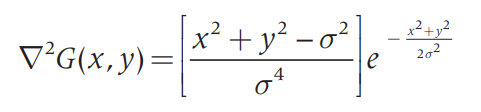


O filtro DoG é uma simplificação do filtro LoG, onde a diferença entre duas imagens suavizadas por filtros Gaussiano diferentes é calculada. Este filtro é utilizado principalmente para realçar bordas.
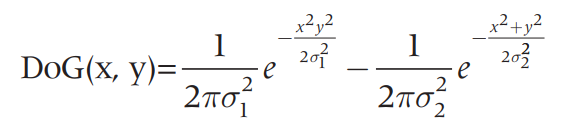

Se tivermos uma imagem de exemplo e nela fossem aplicados os dois filtros separados teríamos por exemplo:
Com o filtro LoG uma imagem com bordas mais definidas, mas podendo resultar em respostas sensíveis a ruído devido à natureza da segunda derivada.
Já com o filtro DoG, por sua vez, o resultado seria mais suave e poderia ser menos sensível a ruído, realçando efetivamente bordas em escalas diferentes.

## Q4) Tente definir com as suas palavras o que é textura em uma imagem. Por que ela é importante na tarefa de segmentação de imagens?

Textura em uma imagem pode ser definido como um padrão de relação entre pixeis de uma determinada região da imagem.

São muito utilizadas na segmentação de imagens, pois permitem que sejam diferenciados os objetos de uma imagem, além de permitir a separação de ambientes, mesmo que possuam a mesma cor.